<a href="https://colab.research.google.com/github/JOSHNA-97886/projects/blob/main/ML_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
from sklearn import model_selection, metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import matplotlib.pylab as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [ ]:
!wget https://s3.amazonaws.com/ibm-sample-cust-churn-data/WA_Fn-UseC_-Telco-Customer-Churn.csv

--2025-02-07 13:50:51--  https://s3.amazonaws.com/ibm-sample-cust-churn-data/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.129.16, 52.216.36.112, 3.5.12.104, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.129.16|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-02-07 13:50:52 ERROR 404: Not Found.



In [ ]:
ls -l

total 676
-rw-r--r-- 1 root root 684858 Feb  7 13:50 Churn_Modelling.csv
drwxr-xr-x 1 root root   4096 Feb  5 14:21 sample_data/


In [ ]:
data=pd.read_csv('/content/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data['Balance'] = pd.to_numeric(data['Balance'], errors = 'coerce')
data.loc[data['Balance'].isna()==True]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [ ]:
data[data['Balance'].isna()==True] = 0
data['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [ ]:
data.shape

(10000, 14)

In [ ]:
data = data.drop(columns=["RowNumber", "CustomerId", "Surname"])

data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

data = pd.get_dummies(data, columns=["Geography"], drop_first=True)

print(data.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       1   42       2       0.00              1          1   
1          608       1   41       1   83807.86              1          0   
2          502       1   42       8  159660.80              3          1   
3          699       1   39       1       0.00              2          0   
4          850       1   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False            False  
3               0         93826.63       0              False            False  
4               1         79084.10       0              False             True  


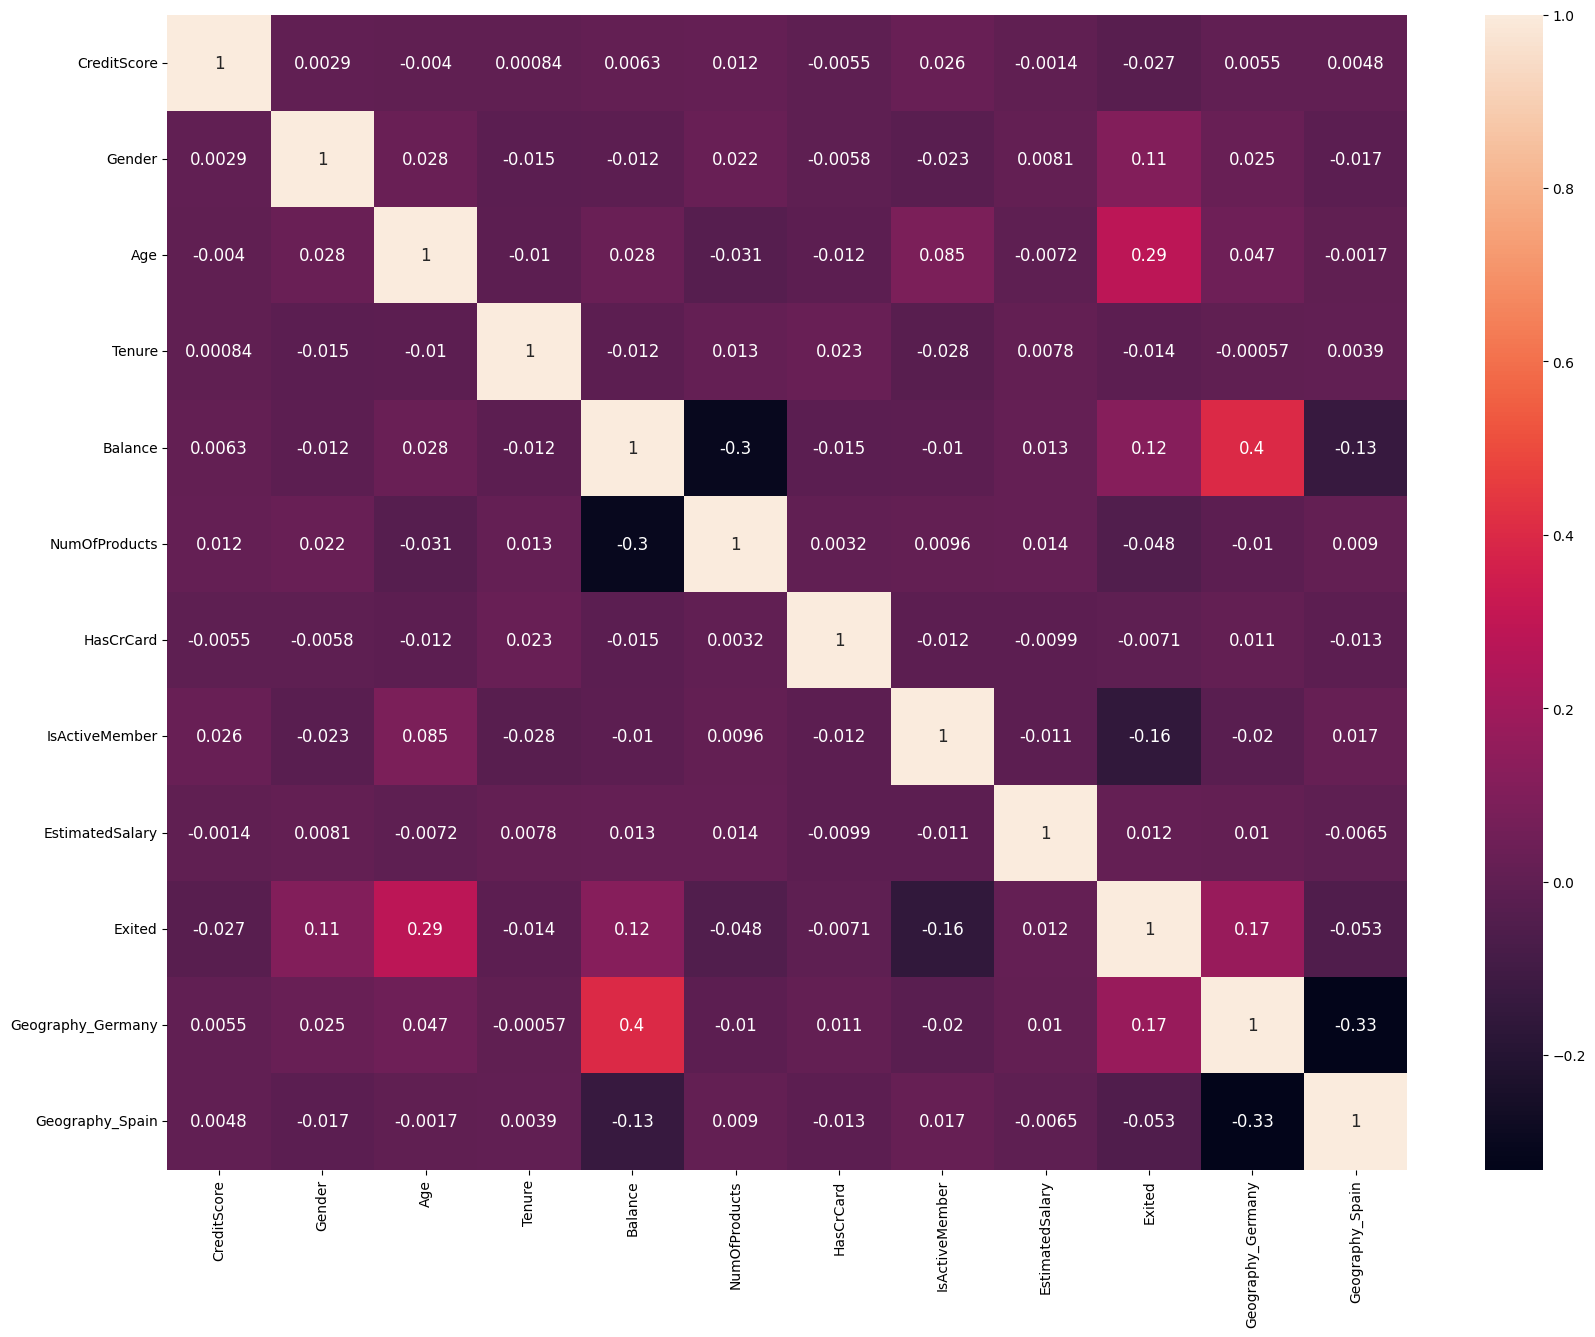

In [ ]:
corr = data.corr()
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot = True, annot_kws={'size':12})
heat_map=plt.gcf()
heat_map.set_size_inches(20,15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [ ]:
data.pop('Balance')

,Balance
0,0.00
1,83807.86
2,159660.80
3,0.00
4,125510.82
...,...
9995,0.00
9996,57369.61
9997,0.00
9998,75075.31


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(1), int64(8)
memory usage: 722.8 KB


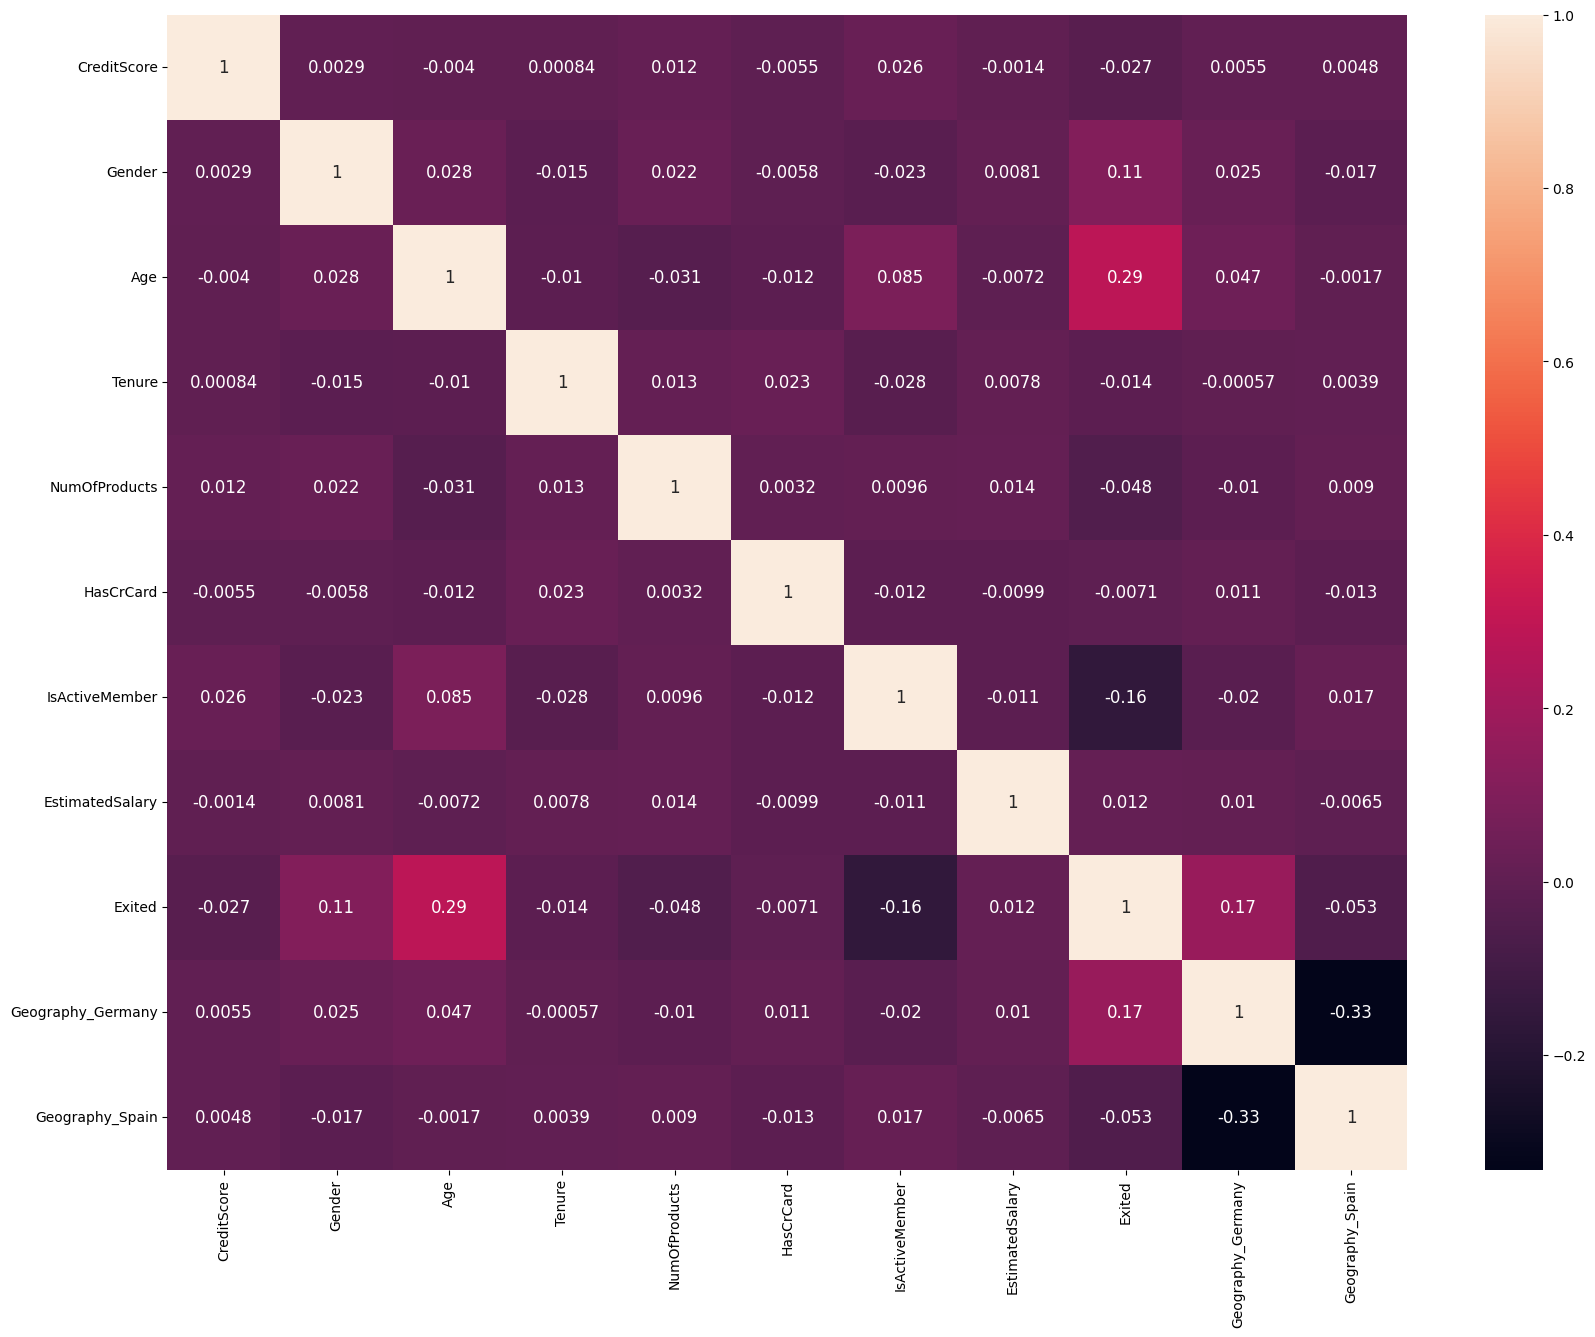

In [ ]:
corr = data.corr()
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot = True, annot_kws={'size':12})
heat_map=plt.gcf()
heat_map.set_size_inches(20,15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [ ]:
print(len(data['Age']))

10000


In [ ]:
data['Age'].value_counts()

,count
Age,
37,478
38,477
35,474
36,456
34,447
...,...
92,2
82,1
88,1


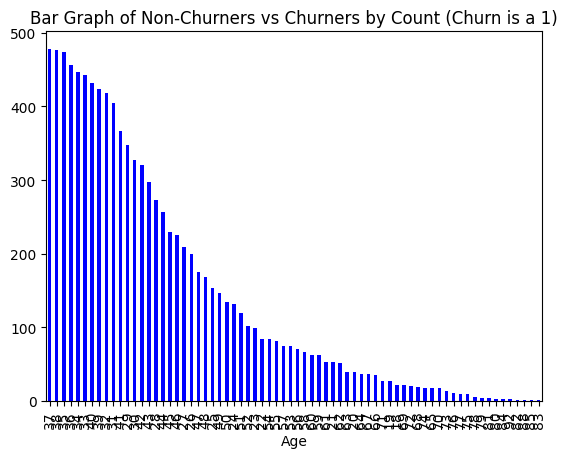

In [ ]:
data['Age'].value_counts().plot(kind = 'bar', title = 'Bar Graph of Non-Churners vs Churners by Count (Churn is a 1)', color = 'blue', align = 'center')
plt.show()

In [ ]:
Gender_Age_contingency = pd.crosstab(data["Gender"], data["Age"])
display(Gender_Age_contingency)

Age,18,19,20,21,22,23,24,25,26,27,...,78,79,80,81,82,83,84,85,88,92
Gender,,,,,,,,,,,,,,,,,,,,,
0,18,18,27,20,42,57,72,85,106,105,...,2,1,2,2,0,1,1,0,1,2
1,4,9,13,33,42,42,60,69,94,104,...,3,3,1,2,1,0,1,1,0,0


<Axes: >

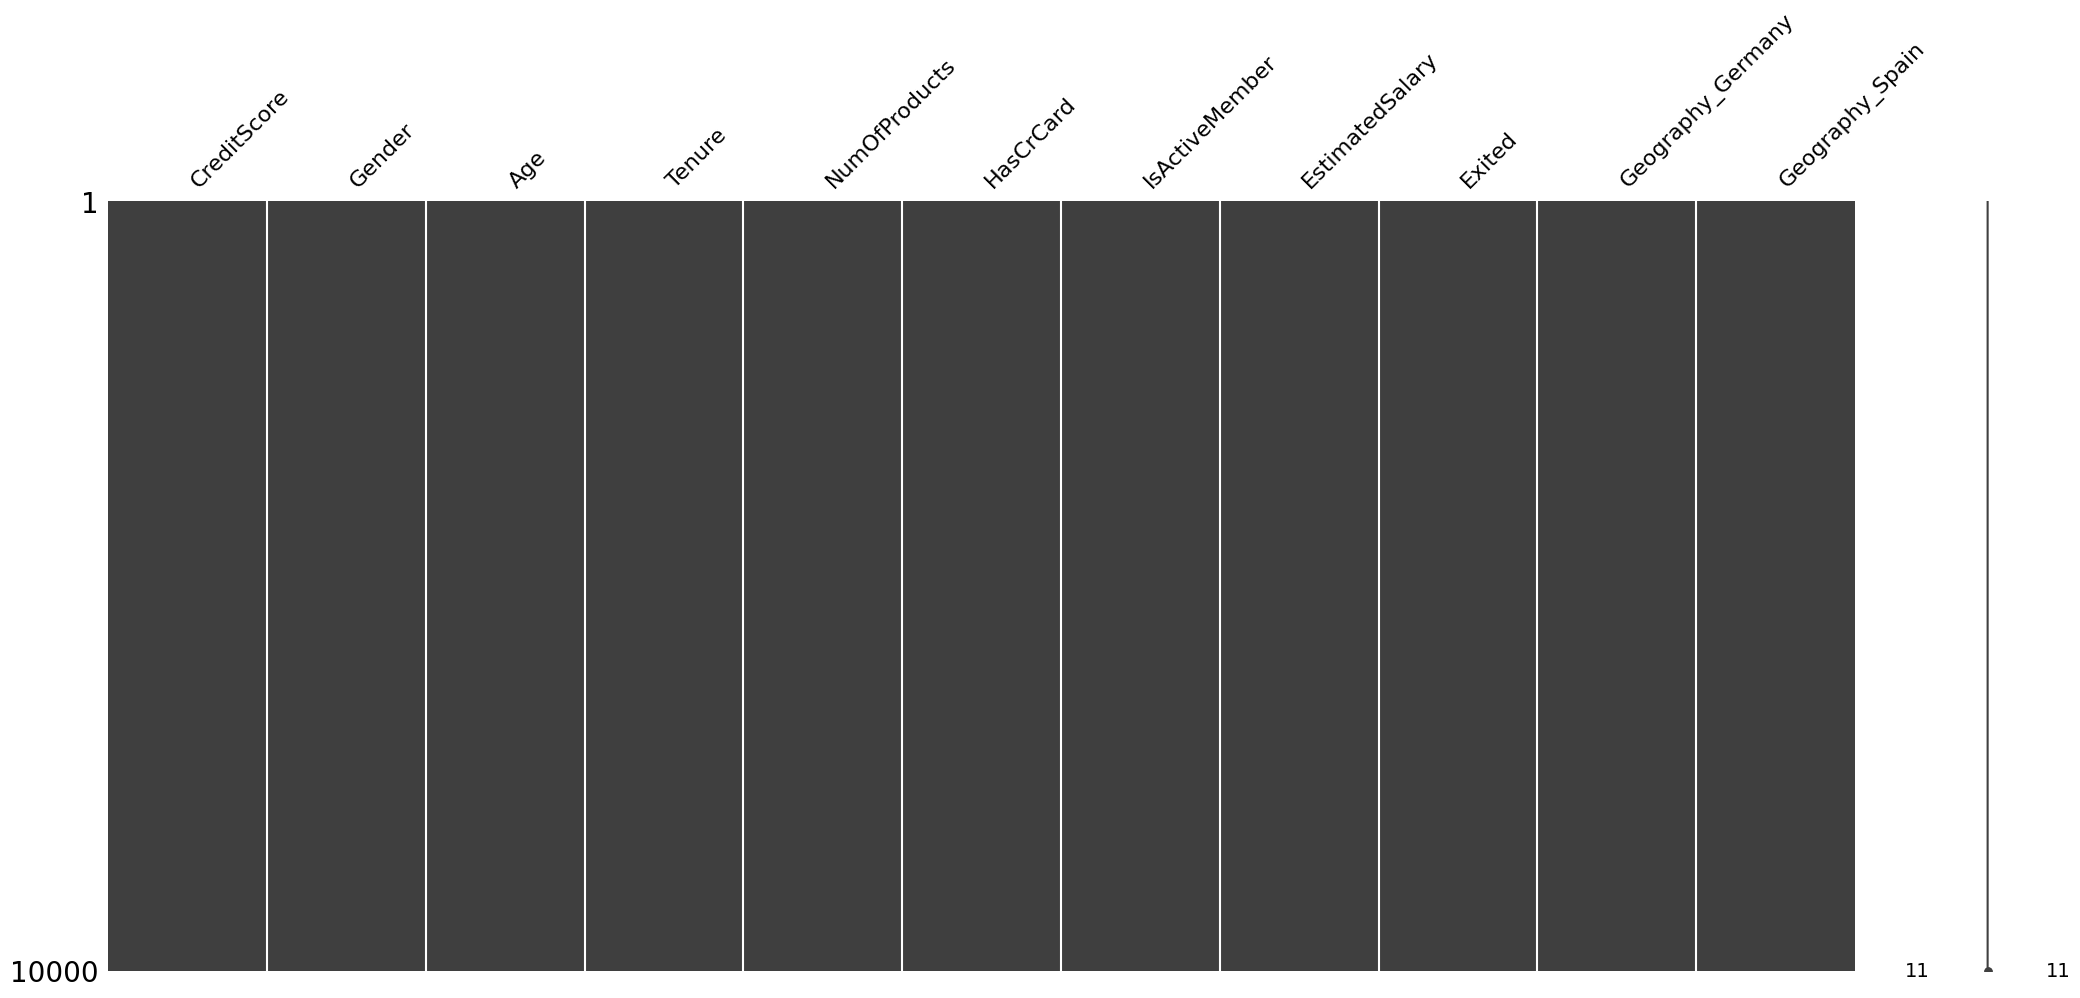

In [ ]:
ms.matrix(data)

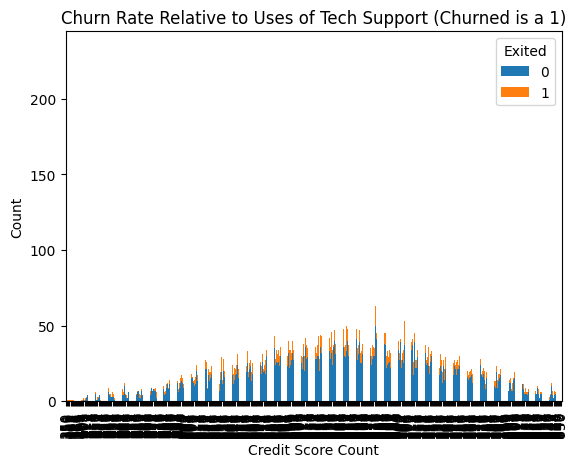

In [ ]:
Credit_Score_Exited = pd.crosstab(data['CreditScore'], data['Exited'])
Credit_Score_Exited.plot(kind = 'bar', stacked = True)
plt.ylabel('Count')
plt.xlabel('Credit Score Count')
plt.title('Churn Rate Relative to Uses of Tech Support (Churned is a 1)')
plt.show()

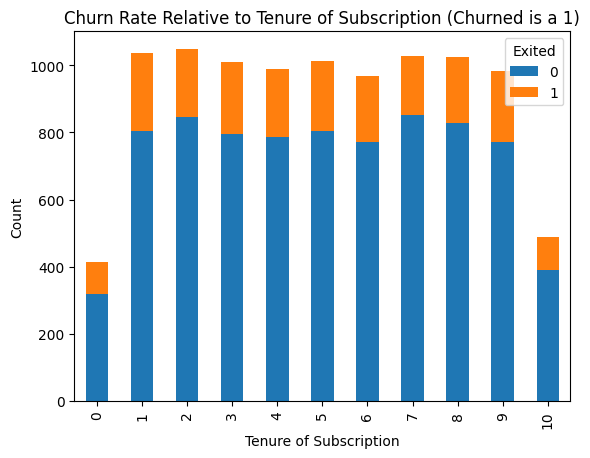

In [ ]:
Tenure_Exited = pd.crosstab(data['Tenure'], data['Exited'])
Tenure_Exited.plot(kind = 'bar', stacked = True)
plt.ylabel('Count')
plt.xlabel('Tenure of Subscription')
plt.title('Churn Rate Relative to Tenure of Subscription (Churned is a 1)')
plt.show()

In [ ]:
features = ['CreditScore', 'Gender','Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited','Geography_Germany', 'Geography_Spain']
data[features].describe()

,CreditScore,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.454300,38.921800,5.012800,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.497932,10.487806,2.892174,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,18.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,0.000000,37.000000,5.000000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,1.000000,92.000000,10.000000,4.000000,1.00000,1.000000,199992.480000,1.000000


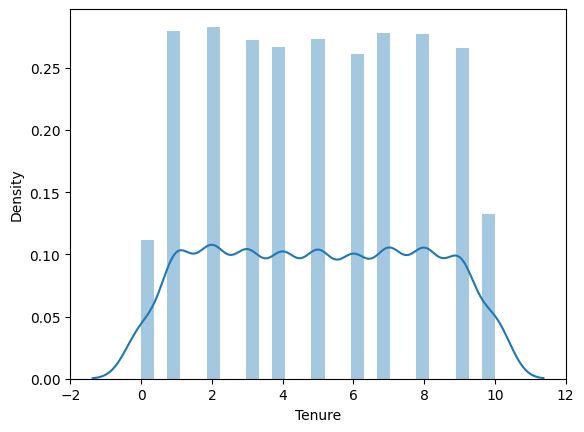

In [ ]:
sns.distplot(data['Tenure']);

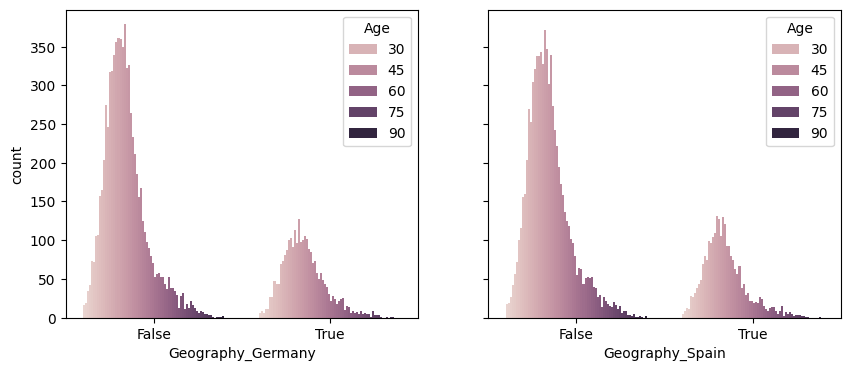

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.countplot(x='Geography_Germany', hue='Age',
              data=data, ax=axes[0]);
sns.countplot(x='Geography_Spain', hue='Age',
              data=data, ax=axes[1]);

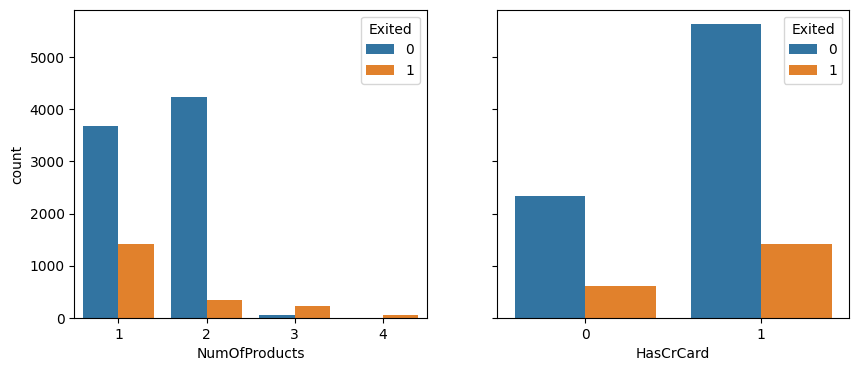

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
sns.countplot(x='NumOfProducts', hue='Exited',
              data=data, ax=axes[0]);
sns.countplot(x='HasCrCard', hue='Exited',
              data=data, ax=axes[1]);

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('Exited',axis=1),
                                                    data['Exited'], test_size=0.30,
                                                    random_state=101)

In [ ]:
train=pd.concat([X_train,y_train],axis=1)

In [ ]:
def modelfit(alg, dtrain, predictors,useTrainCV=True, cv_folds=5, early_stopping_rounds=50):

    if useTrainCV:
        #to get the parameters of xgboost
        xgb_param = alg.get_xgb_params()

        #to convert into a datastructure internally used by xgboost for training efficiency
        # and speed
        xgtrain = xgb.DMatrix(dtrain[predictors].values, label=dtrain[target].values)

        #xgb.cv is used to find the number of estimators required for the parameters
        # which are set
        cvresult = xgb.cv(xgb_param, xgtrain,
                          num_boost_round=alg.get_params()['n_estimators'], nfold=cv_folds,
                        metrics='auc', early_stopping_rounds=early_stopping_rounds)

        #setting the n_estimators parameter using set_params
        alg.set_params(n_estimators=cvresult.shape[0])

        print(alg.get_xgb_params())

    #Fit the algorithm on the data
    alg.fit(dtrain[predictors], dtrain['Exited'],eval_metric='auc')

    return alg

In [ ]:
def get_accuracy(alg,predictors):
    dtrain_predictions = alg.predict(X_test[predictors])
    dtrain_predprob = alg.predict_proba(X_test[predictors])[:,1]
    print ("\nModel Report")
    print ("Accuracy : %.4g" % metrics.accuracy_score(y_test.values,
                                                      dtrain_predictions))
    print ("AUC Score (Train): %f" % metrics.roc_auc_score(y_test.values,
                                                           dtrain_predprob))

In [ ]:
def get_feature_importances(alg):
    #to get the feature importances based on xgboost we use fscore
    feat_imp = pd.Series(alg._Booster.get_fscore()).sort_values(ascending=False)
    print(feat_imp)

    #this shows the feature importances on a bar chart
    feat_imp.plot(kind='bar', title='Feature Importances')
    plt.ylabel('Feature Importance Score')

In [ ]:
target = 'Exited'
IDcol = 'CreditScore'

In [ ]:
!pip install xgboost

In [ ]:
def XgbClass(learning_rate =0.1,n_estimators=1000,max_depth=5,min_child_weight=1,
             gamma=0,subsample=0.8,colsample_bytree=0.8):
    xgb1 = XGBClassifier(learning_rate=learning_rate,
                         n_estimators=n_estimators,
                         max_depth=max_depth,
                         min_child_weight=min_child_weight,
                         gamma=gamma,
                         subsample=subsample,
                         colsample_bytree=colsample_bytree)
    return xgb1

In [ ]:
def drop_features(l):
    return [x for x in train.columns if x not in l]

In [ ]:
from xgboost import XGBClassifier
import xgboost as xgb

In [ ]:
!pip install xgboost==1.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.5/173.5 MB 6.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.3
    Uninstalling xgboost-2.1.3:
      Successfully uninstalled xgboost-2.1.3


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='logloss')


In [ ]:
def modelfit(alg, dtrain, predictors):
    alg.fit(dtrain[predictors], dtrain["Exited"])  # Ensure proper fitting
    return alg


In [ ]:
predictors = drop_features([target, IDcol])
print("Predictors:", predictors)  # Ensure it's a valid list

Predictors: ['Gender', 'Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [ ]:
!pip install scikit-learn --upgrade --ignore-installed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.2 which is incompatible.
langchain 0.3.17 requires numpy<2,>=1.22.4; python_version < "3.12", but you have numpy 2.2.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0,

In [ ]:
get_accuracy(first_model,predictors)


Model Report
Accuracy : 0.8367
AUC Score (Train): 0.818057


EstimatedSalary      8543.0
Age                  6076.0
Tenure               3694.0
Gender               1106.0
NumOfProducts        1069.0
IsActiveMember        992.0
Geography_Germany     932.0
HasCrCard             892.0
Geography_Spain       709.0
dtype: float64


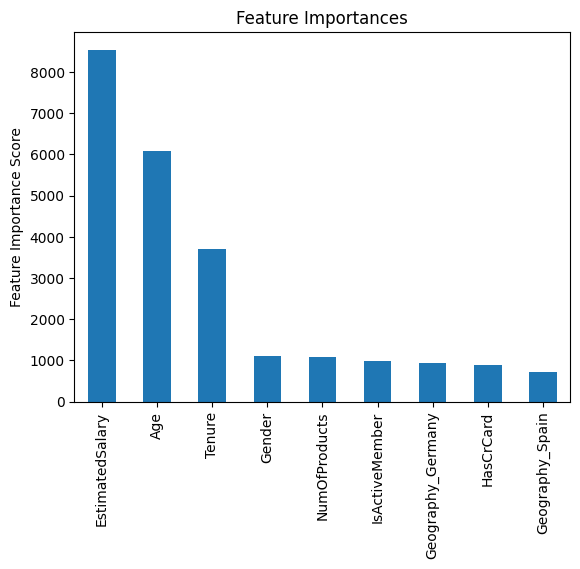

In [ ]:
get_feature_importances(first_model)

In [ ]:
dropl=['EstimatedSalary','Age','Tenure','Gender','NumOfproducts','HasCrCard']

In [ ]:
dropl_first=dropl+[target,IDcol]

In [ ]:
predictors = drop_features(dropl_first)
xgb1 = XgbClass()
second_model=modelfit(xgb1, train, predictors)

In [ ]:
get_accuracy(second_model,predictors)


Model Report
Accuracy : 0.8187
AUC Score (Train): 0.774369


NumOfProducts        3175.0
IsActiveMember       1858.0
Geography_Germany    1591.0
Geography_Spain      1505.0
dtype: float64


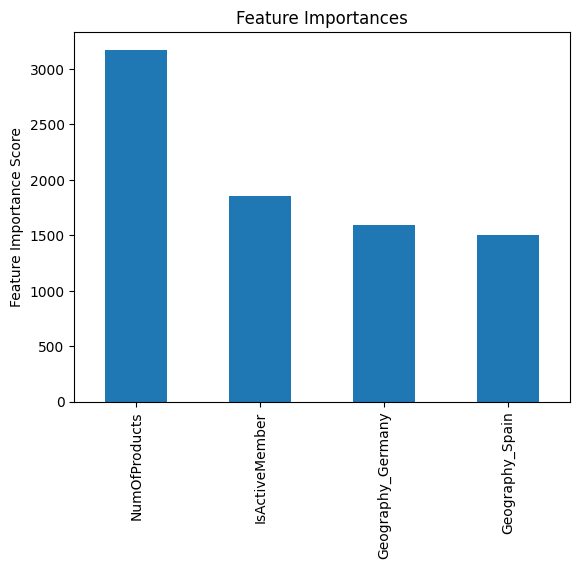

In [ ]:
get_feature_importances(second_model)

In [ ]:
dropl1=dropl+['NumOfproducts','IsActiveMember','Geography_Germany','Geography_Spain','Exited']
dropl_second=dropl_first+['NumOfproducts','IsActiveMember','Geography_Germany','Geography_Spain','Exited']

In [ ]:
predictors=drop_features(dropl_second)

In [ ]:
xgb1=XgbClass()
third_model=modelfit(xgb1,train,predictors)

In [ ]:
get_accuracy(third_model,predictors)


Model Report
Accuracy : 0.8157
AUC Score (Train): 0.711777


In [ ]:
predictors = drop_features(dropl_first)
predictors

['NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain']